In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('Downloads/dataset.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


 Lets understand the features.

 Heart Disease Dataset - Features Description
 ==============================

- age       : Age of the person
- sex       : Gender (1 = Male, 0 = Female)
- cp        : Chest pain type (0–3)
- trestbps  : Resting blood pressure
- chol      : Serum cholesterol level
- fbs       : Fasting blood sugar (1 = >120 mg/dl, 0 = <=120 mg/dl)
- restecg   : Resting ECG results
- thalach   : Maximum heart rate achieved
- exang     : Exercise induced angina (1 = Yes, 0 = No)
- oldpeak   : ST depression induced by exercise
- slope     : Slope of peak exercise ST segment
- ca        : Number of major vessels (0–3)
- thal      : Thalassemia type
- target    : Heart disease (1 = Present, 0 = Not Present)


In [17]:
# Basic Data Preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


- Have 303 rows with 14 columns

In [20]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [33]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


- Statistical viewpoint

In [38]:
df.duplicated().sum()

1

In [42]:
df = df.drop_duplicates()

In [46]:
df.duplicated().sum()

0

In [48]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [51]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

# EDA (Exploratory Data Analysis)

- Countplot = Used when you want to count frequency of categories.

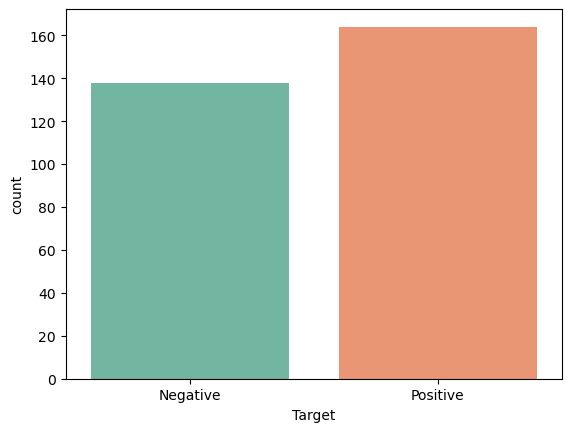

In [67]:
sns.countplot(x='target', data=df, palette='Set2')
plt.xticks([0,1], ['Negative', 'Positive'])
plt.xlabel('Target')
plt.show()

In [69]:
df['sex'].unique()

array([1, 0], dtype=int64)

- 0 = Female
- 1 = Male

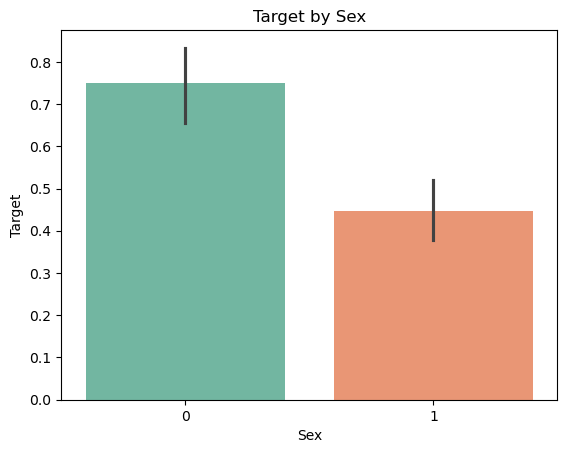

In [85]:
sns.barplot(x='sex', y='target', data=df, palette='Set2')
plt.xlabel('Sex')
plt.ylabel('Target')
plt.title('Target by Sex')
plt.show()

- That means 75% of females have heart disease in this dataset.
- That means 45% of males have heart disease in this dataset.

In [90]:
# Chest Pain(cp) analysis.
df['cp'].unique()

array([3, 2, 1, 0], dtype=int64)

- 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic

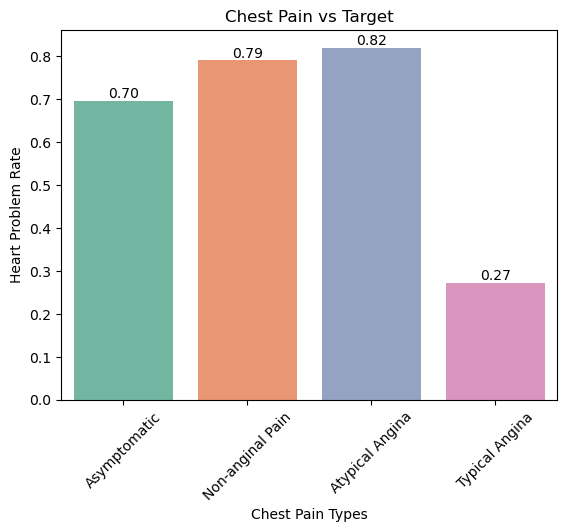

In [130]:
df['cp_label'] = df['cp'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
})
ax = sns.barplot(x='cp_label',y='target', data=df, palette='Set2', errorbar=None)
# Add values on top
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
    
plt.xlabel('Chest Pain Types')
plt.xticks(rotation=45)
plt.ylabel('Heart Problem Rate')
plt.title('Chest Pain vs Target')
plt.show()

- Notice, Typically who have chest pain of Typical Angina(0) have less Heart Problem

In [134]:
# trestbps : Resting blood pressure Analysis
df['trestbps'].value_counts()

trestbps
120    37
130    36
140    32
110    19
150    17
128    12
138    12
160    11
125    11
112     9
132     8
118     7
124     6
135     6
108     6
152     5
134     5
145     5
122     4
170     4
100     4
105     3
126     3
115     3
180     3
136     3
142     3
102     2
148     2
178     2
94      2
144     2
146     2
200     1
114     1
154     1
123     1
192     1
174     1
165     1
104     1
117     1
101     1
156     1
106     1
155     1
129     1
172     1
164     1
Name: count, dtype: int64

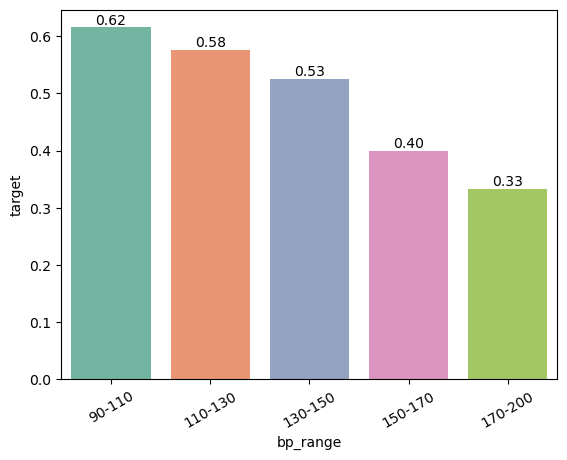

In [158]:
df['bp_range'] = pd.cut(
    df['trestbps'],
    bins=[90,110,130,150,170,200],
    labels=['90-110','110-130','130-150','150-170','170-200']
)
df.groupby('bp_range')['target'].mean()
bx = sns.barplot(x='bp_range', y='target', data=df, errorbar=None, palette='Set2')
for i in bx.containers:
    bx.bar_label(i, fmt='%.2f')
plt.xticks(rotation=30)
plt.show()


- trestbps = resting blood pressure(bp_range)
- Heart disease rate appears higher in lower resting blood pressure ranges (90–130).
- As resting blood pressure increases beyond 130, the disease rate decreases in this dataset.
- This suggests trestbps alone may not have a direct positive correlation with heart disease.


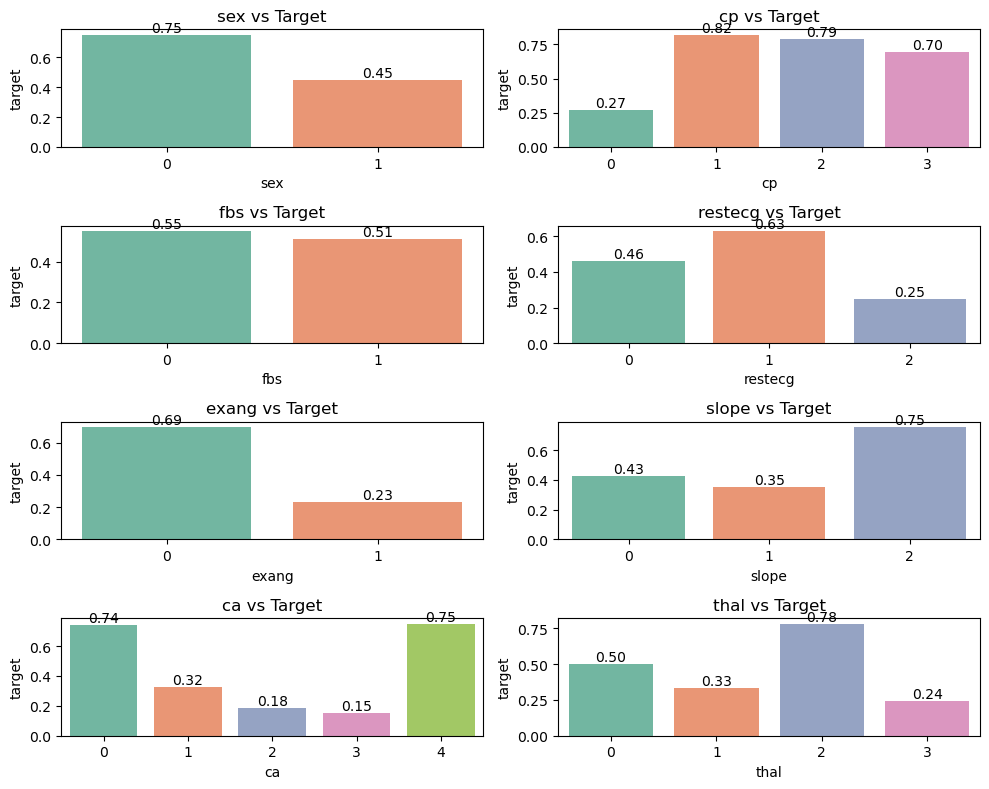

In [173]:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

fig, axes = plt.subplots(4, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax=sns.barplot(x=col, y='target', data=df, ax=axes[i], errorbar=None, palette='Set2')
    axes[i].set_title(f"{col} vs Target")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()


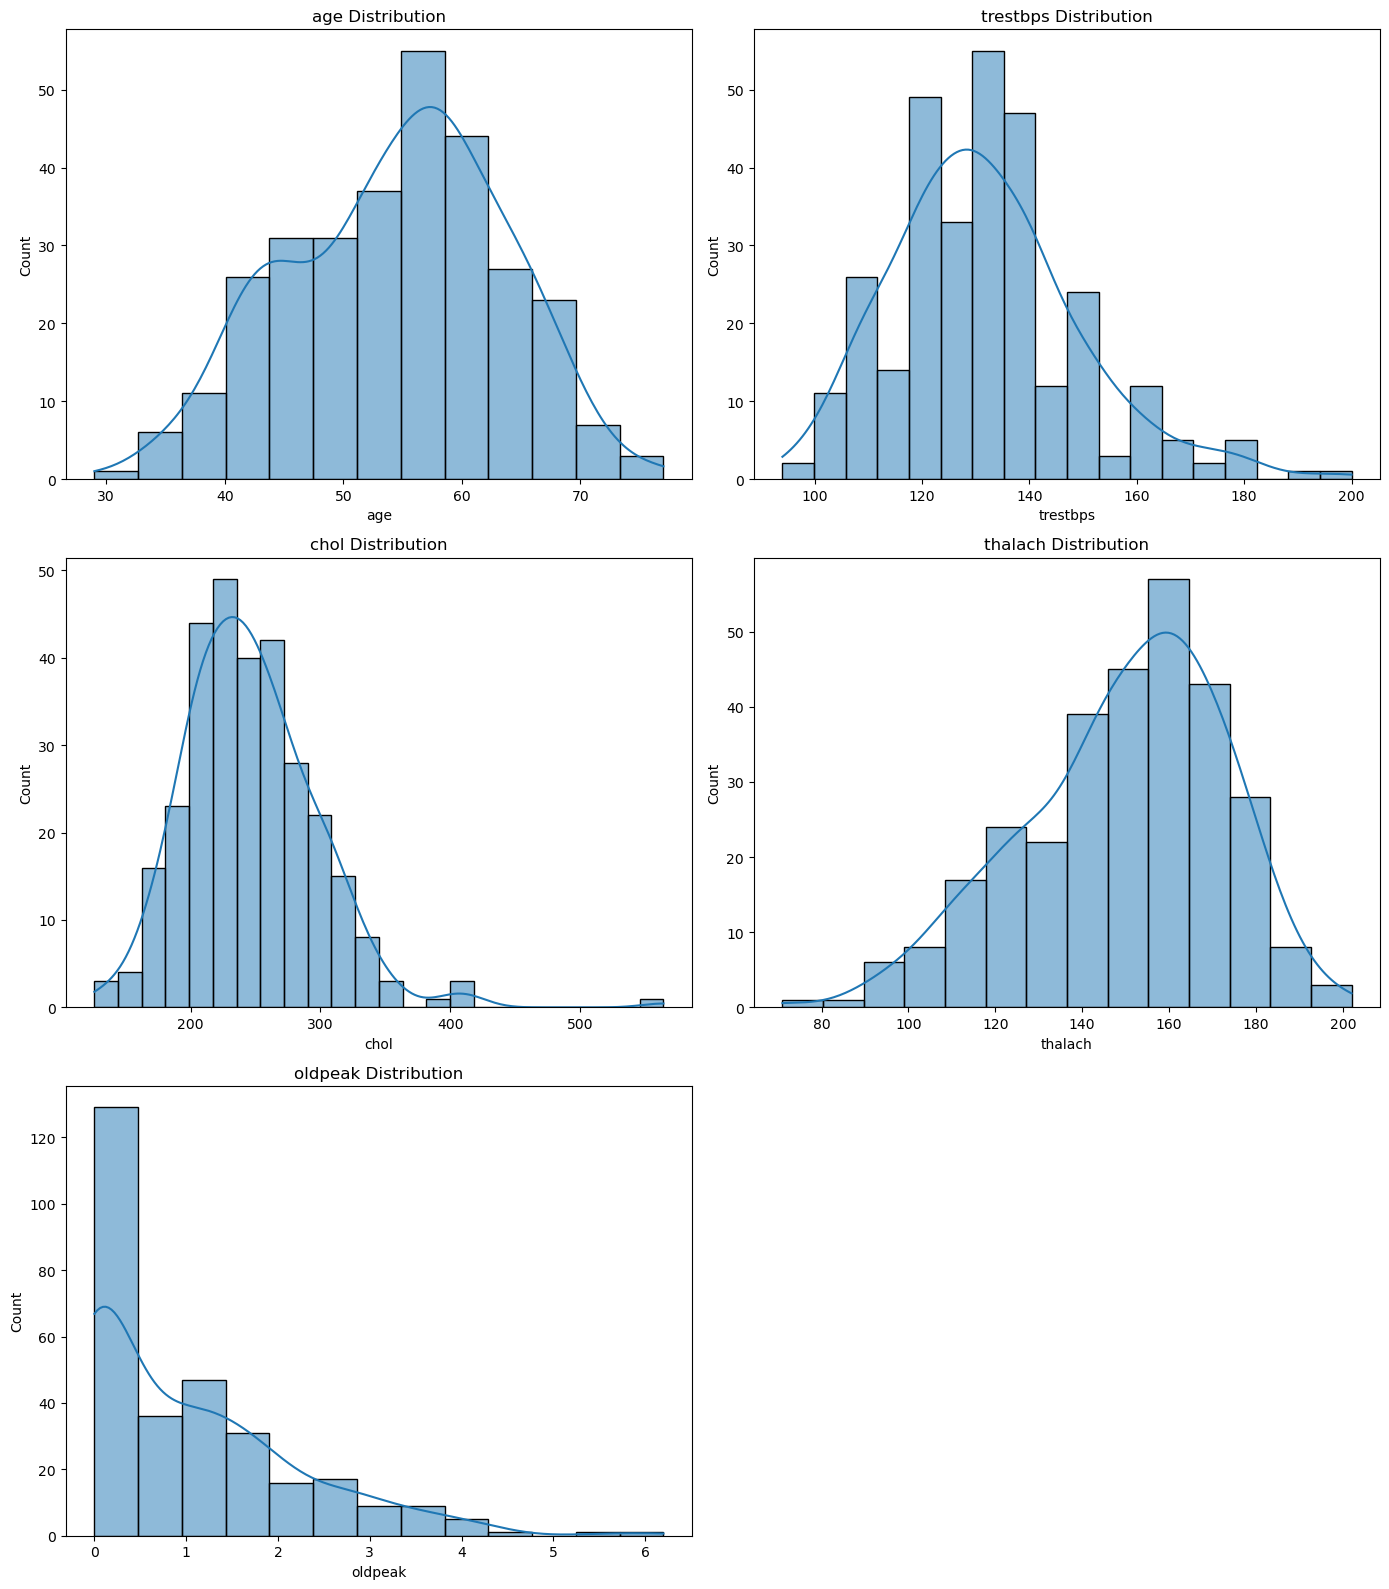

In [181]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Remove extra empty subplot (since we created 6 slots but have 5 features)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [183]:
df = df[df['chol'] <= 500]


In [185]:
df[df['chol'] > 500]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_label,bp_range


In [189]:
df.shape

(301, 16)

In [191]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,        
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Asymptomatic'

<Figure size 1200x800 with 0 Axes>

In [193]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_label,bp_range
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Asymptomatic,130-150
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Non-anginal Pain,110-130
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Atypical Angina,110-130
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Atypical Angina,110-130
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Typical Angina,110-130


In [195]:
df.drop(columns=['cp_label', 'bp_range'], inplace=True)

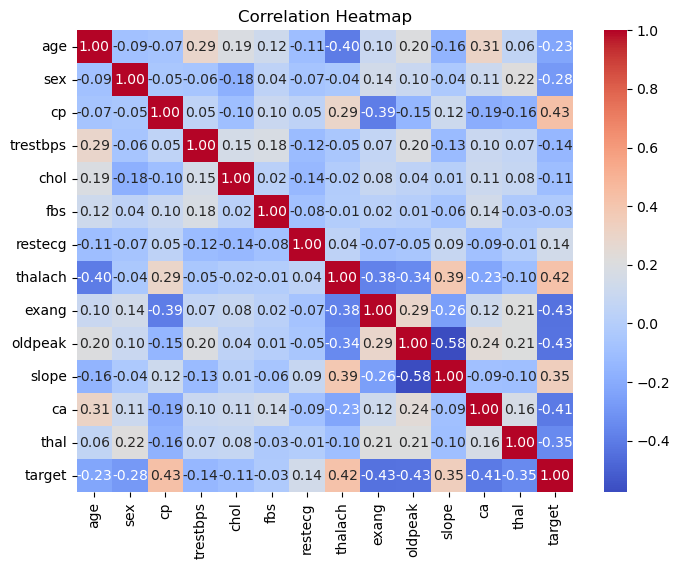

In [199]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,        
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Train-Test Split

In [202]:
from sklearn.model_selection import train_test_split

In [204]:
X = df.drop('target', axis=1)
y = df['target']

X_train,X_test,Y_train,Y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [206]:
X_train.shape

(240, 13)

In [208]:
X_test.shape

(61, 13)

In [212]:
print(Y_train.shape)
print(Y_test.shape)

(240,)
(61,)


In [214]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression

In [278]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()

log.fit(X_train,Y_train)
Y_pred_log = log.predict(X_test) 

In [219]:
Y_pred_log.shape

(61,)

In [346]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(Y_test, Y_pred_log)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_log))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_log))
log_acc = accuracy_score(Y_test, Y_pred_log)


Accuracy: 83.60655737704919 %

Confusion Matrix:
 [[21  7]
 [ 3 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



Confusion Matrix:
- 21 → Correctly predicted No Disease
- 30 → Correctly predicted Disease
- 7 → False Positives
- 3 → False Negatives

# Decision Tree

In [270]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [272]:
print(Y_pred_dt.shape)

(61,)


In [348]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_dt)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_dt))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_dt))

dt_acc = accuracy_score(Y_test, Y_pred_dt)


Accuracy: 75.40983606557377 %

Confusion Matrix:
 [[22  6]
 [ 9 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75        28
           1       0.80      0.73      0.76        33

    accuracy                           0.75        61
   macro avg       0.75      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61



# Random Forest 

In [297]:
from sklearn.ensemble import RandomForestClassifier
max_accuracy = 0


for x in range(200):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

rf = RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [299]:
print(Y_pred_rf.shape)

(61,)


In [350]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rf))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_rf))

rf_acc = accuracy_score(Y_test, Y_pred_rf)


Accuracy: 86.88524590163934 %

Confusion Matrix:
 [[23  5]
 [ 3 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



# Naive Bias

In [306]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb.fit(X_train, Y_train)
Y_pred_nb = nb.predict(X_test)


In [308]:
Y_pred_nb.shape

(61,)

In [358]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_nb)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_nb))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_nb))

nb_acc = accuracy_score(Y_test, Y_pred_nb)

Accuracy: 80.32786885245902 %

Confusion Matrix:
 [[23  5]
 [ 7 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79        28
           1       0.84      0.79      0.81        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



# SVM

In [315]:
from sklearn import svm
sv = svm.SVC(kernel='linear')
sv.fit(X_train,Y_train)
Y_pred_sv = sv.predict(X_test)

In [319]:
Y_pred_sv.shape

(61,)

In [356]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_sv)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_sv))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_sv))

svm_acc = accuracy_score(Y_test, Y_pred_sv)

Accuracy: 83.60655737704919 %

Confusion Matrix:
 [[21  7]
 [ 3 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



# K Nearest Neighbors

In [329]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn = knn.predict(X_test)

In [331]:
Y_pred_knn.shape

(61,)

In [352]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_knn)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_knn))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_knn))

knn_acc = accuracy_score(Y_test, Y_pred_knn)


Accuracy: 80.32786885245902 %

Confusion Matrix:
 [[21  7]
 [ 5 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



# XGBoost

In [336]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic',random_state=42)
xgb_model.fit(X_train,Y_train)
Y_pred_xgb_model = xgb_model.predict(X_test)

In [360]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_xgb_model)*100,'%')
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_xgb_model))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_xgb_model))

xgb_acc = accuracy_score(Y_test, Y_pred_xgb_model)

Accuracy: 83.60655737704919 %

Confusion Matrix:
 [[22  6]
 [ 4 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [362]:

models = {
    "Logistic Regression": log_acc,
    "KNN": knn_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "SVM": svm_acc,
    "Naive Bayes": nb_acc,
    "XGBoost": xgb_acc
}

model_df = pd.DataFrame(list(models.items()), columns=["Model", "Accuracy"])

# Sort from Best to Worst
model_df = model_df.sort_values(by="Accuracy", ascending=False)

# Convert accuracy to percentage
model_df["Accuracy (%)"] = model_df["Accuracy"] * 100

model_df


,Model,Accuracy,Accuracy (%)
3,Random Forest,0.868852,86.885246
0,Logistic Regression,0.836066,83.606557
4,SVM,0.836066,83.606557
6,XGBoost,0.836066,83.606557
1,KNN,0.803279,80.327869
5,Naive Bayes,0.803279,80.327869
2,Decision Tree,0.754098,75.409836


- Winner is **Random Forest** with 87% accuracy.

In [376]:
# -------------------------------------------------------------
# Saving Random Forest Model using Pipeline (Recommended Way)
# -------------------------------------------------------------
# Instead of saving the model and scaler separately,
# we use a Pipeline to combine preprocessing (StandardScaler)
# and the RandomForest model into one single object.
#
# This ensures:
# 1. New input data will automatically be scaled before prediction.
# 2. We avoid mismatch errors during deployment.
# 3. Model + preprocessing are saved together in one .pkl file.
# -------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pickle

# Create Pipeline (Scaler + Model)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

# Train Pipeline
pipeline.fit(X_train, Y_train)

# Save Pipeline as Pickle file
pickle.dump(pipeline, open("rf_pipeline.pkl", "wb"))

print("Pipeline model saved successfully!")


Pipeline model saved successfully!
